# 4.3 — Transfer learning : réutiliser un ResNet18 pré-entraîné

[<- DataScienceWithAgents (série parente)](../README.md) | [4.1 — Le neurone convolutif from scratch](4.1-Conv-NumPy-Torch-Allclose.ipynb) | [4.2 — ConvNet profonde : pourquoi les résiduelles](4.2-ConvNet-Profonde-Residuelles.ipynb) | [3.4 — Attention Transformer from scratch](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb)

**Kernel** : Python 3 (`coursia-ml-training` compatible) - **Bibliothèques** : PyTorch, torchvision (poids ImageNet de ResNet18 téléchargés au premier run, ~45 Mo, puis en cache), matplotlib - **Niveau** : intermédiaire (post 4.2) - **CPU** : oui (entraînement borné, budget total mesuré en section 5)

## Pourquoi ce notebook

[4.2](4.2-ConvNet-Profonde-Residuelles.ipynb) a établi *pourquoi* un ResNet de 18 couches est entraînable : les connexions résiduelles maintiennent le gradient vivant. Mais entraîner ce réseau de zéro sur ImageNet demande 1,2 million d'images étiquetées et des dizaines d'heures GPU. Dans la pratique, presque personne ne fait ça : on **réutilise** un réseau déjà entraîné ailleurs. C'est le *transfer learning*, et c'est le geste le plus courant du deep learning appliqué.

**La thèse de ce notebook** : le backbone pré-entraîné est un **extracteur de caractéristiques réutilisable**, et la vraie question devient *combien* on réutilise. Deux régimes extrêmes encadrent le choix :

| régime | paramètres entraînés | ce qu'on apprend |
|---|---|---|
| **gelé** (feature extraction) | la tête seulement (5 130) | une frontière linéaire sur des caractéristiques figées |
| **fine-tuné** | tout le réseau (~11,2 M) | à la fois la frontière *et* les caractéristiques |

La réponse n'est pas universelle : elle **dépend du décalage de domaine** entre le pré-entraînement et la cible, et cela se mesure. On mesurera sur **EuroSAT** — dix classes d'occupation du sol en images satellite Sentinel-2 (64 x 64 pixels). Le décalage avec ImageNet (photos terrestres, chat, voiture, avion) est ici presque maximal : si le fine-tuning doit un jour payer, c'est sur ce terrain.

**Plan** : (1) le domaine cible et son décalage, (2) greffer une nouvelle tête sur ResNet18, (3) le régime gelé, (4) le régime fine-tuné, (5) comparaison sur 3 graines avec test apparié, (6) exercices, (7) ce qu'il faut retenir.


***

## 1. Le domaine cible : mille images, pas 1,2 million


**Le contrat de données du praticien.** EuroSAT contient 27 000 vignettes Sentinel-2 de 64 x 64 pixels, équiréparties en 10 classes d'occupation du sol. Pour rester dans le budget CPU de la série, on n'en utilisera qu'un **sous-ensemble borné et déterministe** : 80 images d'entraînement et 30 de validation par classe, soit 1 100 images au total — environ **0,1 %** du volume ImageNet. C'est précisément le régime où le transfer learning est censé être irremplaçable : trop peu de données pour espérer entraîner un extracteur de zéro, assez pour calibrer une tête.

**Pourquoi 112 pixels et pas 224.** Le pré-entraînement ImageNet attend des entrées ~224 x 224 ; EuroSAT est natif 64 x 64. Ré-échantillonner à 112 (x 1,75) suffit à donner au stem du ResNet une carte de caractéristiques exploitable, et divise par ~4 le coût CPU du forward par rapport à 224 — c'est la borne qui tient ce notebook sous les 10 minutes. Le compromis est mesuré, pas subi : il sera visible dans les accuracies de la section 5.


In [1]:
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import EuroSAT
from torchvision.models import ResNet18_Weights, resnet18

torch.set_num_threads(8)  # 4.2 travaillait a 4 threads ; ici le forward ResNet18 est le poste de cout.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GRAINES = (0, 1, 2)
PAR_CLASSE_TRAIN, PAR_CLASSE_VAL = 80, 30
TAILLE = 112

print(f"torch {torch.__version__} | device = {DEVICE} | threads CPU = {torch.get_num_threads()}")
print(f"graines = {GRAINES} | {PAR_CLASSE_TRAIN} train + {PAR_CLASSE_VAL} val par classe")

torch 2.13.0+cpu | device = cpu | threads CPU = 8
graines = (0, 1, 2) | 80 train + 30 val par classe


**Chargement et découpage.** Le cache du dataset vit hors du dépôt (même convention que 4.2 : `~/.cache/coursia-datasets`, ~94 Mo au premier run, partagé entre les notebooks de la série). La graine pilote à la fois le choix des images par classe et l'ordre de présentation — deux exécutions sous la même graine voient exactement les mêmes données. C'est ce qui rend la comparaison des régimes *appariée* : à graine fixée, gelé et fine-tuné travaillent sur le même split.

In [2]:
MOYENNE_IMAGENET = [0.485, 0.456, 0.406]
ECART_TYPE_IMAGENET = [0.229, 0.224, 0.225]
# Normalisation ImageNet : obligatoire pour consommer des poids pre-entraines dessus.

TRANSFORM = transforms.Compose([
    transforms.Resize(TAILLE),
    transforms.ToTensor(),
    transforms.Normalize(MOYENNE_IMAGENET, ECART_TYPE_IMAGENET),
])

RACINE_DONNEES = Path.home() / ".cache" / "coursia-datasets"

donnees = EuroSAT(root=str(RACINE_DONNEES), transform=TRANSFORM, download=True)
CIBLES_DATASET = np.array(donnees.targets)

NOMS_FR = {
    "AnnualCrop": "cultures annuelles", "Forest": "foret",
    "HerbaceousVegetation": "vegetation herbeuse", "Highway": "autoroute",
    "Industrial": "zone industrielle", "Pasture": "paturage",
    "PermanentCrop": "culture permanente", "Residential": "residentiel",
    "River": "riviere", "SeaLake": "mer ou lac",
}
LIBELLES = [NOMS_FR[c] for c in donnees.classes]


def sous_ensemble(graine):
    """Tire PAR_CLASSE_TRAIN + PAR_CLASSE_VAL images par classe, melangees.

    Deterministe par graine : le meme split pour les deux regimes.
    """
    rng = np.random.default_rng(graine)
    idx_train, idx_val = [], []
    for c in range(len(donnees.classes)):
        pool = rng.permutation(np.where(CIBLES_DATASET == c)[0])
        idx_train += list(pool[:PAR_CLASSE_TRAIN])
        idx_val += list(pool[PAR_CLASSE_TRAIN:PAR_CLASSE_TRAIN + PAR_CLASSE_VAL])
    rng.shuffle(idx_train)
    rng.shuffle(idx_val)
    return idx_train, idx_val


idx_train, idx_val = sous_ensemble(0)
print(f"{len(donnees)} images au total, {len(donnees.classes)} classes")
print(f"graine 0 : {len(idx_train)} train / {len(idx_val)} validation")

27000 images au total, 10 classes
graine 0 : 800 train / 300 validation


Un coup d'œil avant tout calcul — dix classes, une image chacune :

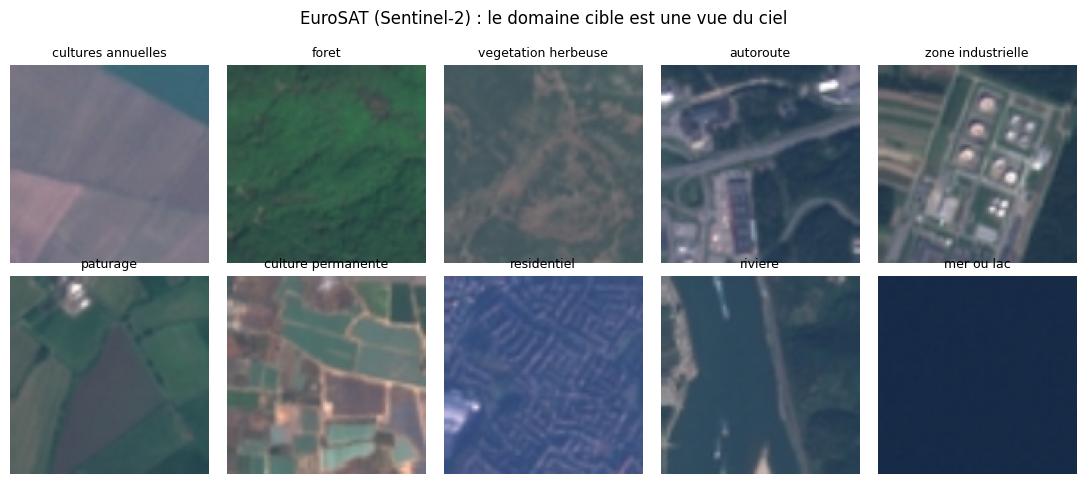

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for ax, c in zip(axes.ravel(), range(10)):
    premier = idx_train[int(np.argmax(CIBLES_DATASET[idx_train] == c))]
    img, cible = donnees[premier]
    vue = img * torch.tensor(ECART_TYPE_IMAGENET).view(3, 1, 1) + torch.tensor(MOYENNE_IMAGENET).view(3, 1, 1)
    ax.imshow(vue.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(LIBELLES[c], fontsize=9)
    ax.axis("off")
fig.suptitle("EuroSAT (Sentinel-2) : le domaine cible est une vue du ciel", y=1.0)
plt.tight_layout()
plt.show()

**Lecture du domaine.** Pas de chat ni de voiture : des parcelles, des toits, des méandres. Les textures dominent les objets, la résolution est grossière, et la **photométrie est celle d'un capteur satellite**, pas d'un appareil photo. C'est un décalage de domaine quasi maximal avec ImageNet — le cas d'école où l'on peut s'attendre à ce que le gel intégral coûte des points et où le fine-tuning doit les récupérer. La section 5 dira combien, avec un intervalle d'incertitude.

Il faut aussi le dire : deux classes (`végétation herbeuse` et `pâturage`) sont visuellement très proches — le genre de confusion qu'une analyse d'erreurs (exercice 3) rendra explicite.


***

## 2. Greffer une nouvelle tête sur ResNet18


**L'anatomie d'un ResNet18.** Le réseau de [4.2](4.2-ConvNet-Profonde-Residuelles.ipynb) est ici en vrai : un *stem* (grande convolution 7 x 7 + maxpool), quatre étages de blocs résiduels (`layer1` à `layer4`, 8 blocs au total), puis une moyenne spatiale et une **tête** `fc` : une simple couche linéaire 512 -> 1000 (les 1000 classes ImageNet). Tout ce qui précède la tête constitue le *backbone* — l'extracteur de caractéristiques.

Le geste du transfer learning tient en une ligne : remplacer `fc` par une linéaire 512 -> 10. On jette la frontière de décision ImageNet (aucune classe ne correspond) et on garde l'extracteur. La vraie question est de savoir **ce que vaut cet extracteur sur notre domaine** — 11,18 millions de paramètres formés sur 1,2 million de photos terrestres, confrontés à des vignettes satellite.

In [4]:
modele_base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # ~45 Mo telecharges au premier run

# La chirurgie : remplacer la tete ImageNet (512 -> 1000) par la notre (512 -> 10).
modele_base.fc = nn.Linear(512, len(donnees.classes))

comptes = {}
for nom, p in modele_base.named_parameters():
    if nom.startswith(("conv1.", "bn1.")):
        cle = "stem (conv1 + bn1)"
    elif nom.startswith(("layer1.", "layer2.", "layer3.", "layer4.")):
        cle = f"{nom.split('.')[0]} (blocs residuels)"
    else:
        cle = "tete fc (remplacee)"
    comptes[cle] = comptes.get(cle, 0) + p.numel()

total = sum(p.numel() for p in modele_base.parameters())
print(f"{'bloc':28s} {'parametres':>12s} {'part':>7s}")
for bloc, n in comptes.items():
    print(f"{bloc:28s} {n:>12,d} {100 * n / total:>6.1f} %")
backbone = total - comptes["tete fc (remplacee)"]
print("-" * 50)
print(f"backbone gele           {backbone:>12,d} {100 * backbone / total:>6.2f} %")
print(f"tete entrainable         {comptes['tete fc (remplacee)']:>12,d} {100 * comptes['tete fc (remplacee)'] / total:>6.2f} %")

bloc                           parametres    part
stem (conv1 + bn1)                  9,536    0.1 %
layer1 (blocs residuels)          147,968    1.3 %
layer2 (blocs residuels)          525,568    4.7 %
layer3 (blocs residuels)        2,099,712   18.8 %
layer4 (blocs residuels)        8,393,728   75.1 %
tete fc (remplacee)                 5,130    0.0 %
--------------------------------------------------
backbone gele             11,176,512  99.95 %
tete entrainable                5,130   0.05 %


**Lecture du compte.** La tête greffée pèse **5 130 paramètres** (512 x 10 + 10 biais) : **0,04 %** du réseau. Geler le backbone, c'est décider d'apprendre avec un budget de paramètres ~2 200 fois plus petit que le fine-tuning complet. Ce ratio n'est pas anecdotique — c'est toute la promesse du régime gelé : *si* les caractéristiques figées sont bonnes, une frontière linéaire de 5 130 poids doit suffire à séparer dix classes d'occupation du sol. La section suivante mesure ce « si ».


***

## 3. Régime gelé : extraction de caractéristiques


**Le protocole.** On fige le backbone (`requires_grad_(False)`, mode `eval` : les statistiques BatchNorm restent celles d'ImageNet, elles ne sont pas ré-estimées). Seule la tête apprend. Comme le backbone ne change plus, ses sorties sont **les mêmes à chaque époque** : on peut les pré-calculer une fois pour toutes — un forward par image au lieu d'un forward par image *et par époque*. La tête entraînée sur ces caractéristiques figées n'est rien d'autre qu'une régression logistique multiclasse : quelques secondes de CPU.

In [5]:
def charger_tenseurs(idx):
    X = torch.stack([donnees[i][0] for i in idx])
    y = torch.tensor([donnees[i][1] for i in idx])
    return X, y


def extraire_caracteristiques(backbone, X, taille_lot=64):
    """Forward du backbone seul (hors tete), sans gradient, par lots."""
    fs = []
    backbone.eval()
    with torch.no_grad():
        for i in range(0, len(X), taille_lot):
            h = backbone.conv1(X[i:i + taille_lot])
            h = backbone.bn1(h); h = backbone.relu(h); h = backbone.maxpool(h)
            h = backbone.layer1(h); h = backbone.layer2(h)
            h = backbone.layer3(h); h = backbone.layer4(h)
            fs.append(backbone.avgpool(h).flatten(1))
    return torch.cat(fs)


def entrainer_gele(graine, epochs_tete=30, taille_lot=64):
    """Regime gele : pre-calcule les features, entraîne la tete dessus."""
    torch.manual_seed(graine)
    it, iv = sous_ensemble(graine)
    Xtr, ytr = charger_tenseurs(it)
    Xva, yva = charger_tenseurs(iv)
    bb = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    t0 = time.time()
    Ftr = extraire_caracteristiques(bb, Xtr)
    Fva = extraire_caracteristiques(bb, Xva)
    duree_features = time.time() - t0
    tete = nn.Linear(512, len(donnees.classes))
    opt = torch.optim.Adam(tete.parameters(), lr=1e-3)
    t0 = time.time()
    for _ in range(epochs_tete):
        perm = torch.randperm(len(Ftr))
        for i in range(0, len(Ftr), taille_lot):
            lot = perm[i:i + taille_lot]
            opt.zero_grad()
            perte = nn.functional.cross_entropy(tete(Ftr[lot]), ytr[lot])
            perte.backward()
            opt.step()
    with torch.no_grad():
        exactitude = (tete(Fva).argmax(1) == yva).float().mean().item()
    return exactitude, duree_features, time.time() - t0


acc_gele_0, duree_feat, duree_tete = entrainer_gele(0)
print(f"regime gele, graine 0 : accuracy val = {100 * acc_gele_0:.1f} %")
print(f"pre-calcul des features : {duree_feat:.0f} s | tete (30 epoques) : {duree_tete:.0f} s")

regime gele, graine 0 : accuracy val = 88.0 %
pre-calcul des features : 7 s | tete (30 epoques) : 0 s


**Lecture du régime gelé.** 88,0 % de bonne classification (graine 0) — avec 5 130 paramètres entraînés et **zéro** pas de gradient dans le backbone. Le compte de paramètres de la section 2 prend ici son sens : le pré-calcul des caractéristiques (7 s) domine tout, et l'entraînement de la tête proprement dit (30 époques) est instantané — c'est la signature du régime : *on paie un forward, on apprend une frontière linéaire*.

Le point remarquable n'est pas le chiffre, c'est ce qu'il dit du pré-entraînement : le hasard vaut 10 %, un extracteur détruit par le changement de domaine vaudrait 30-40 % — or les filtres appris sur des photos de chats et de voitures séparent des parcelles satellites à 88 %. Textures de forêt, bordures de routes, régularité des cultures : une bonne partie de ce qui fait une caractéristique visuelle utile **survit au changement de domaine**. La question de la section suivante devient précise : le fine-tuning peut-il grappiller au-delà de ces 88 %, et à quel prix en calcul ?

***

## 4. Régime fine-tuné : tout dégeler, prudemment


**Le protocole — et pourquoi il a trois garde-fous.** Ici tout le réseau apprend, y compris les 11,18 M paramètres du backbone — mais pas au même rythme : **taux d'apprentissage différenciés**, le choix standard du fine-tuning. La tête (initialisée au hasard) apprend vite (`3e-3`) ; le backbone (déjà excellent, à ne pas casser) s'ajuste lentement (`3e-4`).

Les deux autres garde-fous ne sont pas décoratifs : ils ont été ajoutés après qu'un protocole plus simple les a rendus nécessaires. En essai pilote, le même Adam à taux constants oscillait violemment (des accuracies val en dents de scie, jusqu'à -20 points d'une époque à l'autre) et finissait **sous le régime gelé** en moyenne — et des taux dix fois plus élevés détruisaient d'emblée le pré-entraînement (78,7 % final, sous les 88 % du gelé). D'où : un **planificateur** qui divise les taux par ~3 à chaque époque (l'ajustement fin se fait à pas décroissants, quand le réseau est déjà proche), et un **batch de 64 + weight decay** qui lissent les gradients. C'est une leçon de fine-tuning en soi : *à taux constants, l'optimiseur détruit au 5e pas ce qu'il a construit au 2e*.

Contrairement au régime gelé, le backbone change à chaque pas de gradient : plus question de pré-calculer. Chaque époque repasse les 800 images en forward *et* backward — environ 2,5 x le coût d'un simple forward.

In [6]:
PAS_TETE, PAS_BACKBONE, EPOQUES_FT = 3e-3, 3e-4, 5
GAMMA_SCHED, TAILLE_LOT_FT, WEIGHT_DECAY = 0.3, 64, 1e-4


def entrainer_finetune(graine):
    """Regime fine-tune : tout apprend, lr differencies tete/backbone.

    Stocke le dernier modele dans la globale `dernier_modele` (utilisee
    par l'exercice 3).
    """
    global dernier_modele
    torch.manual_seed(graine)
    it, iv = sous_ensemble(graine)
    Xtr, ytr = charger_tenseurs(it)
    Xva, yva = charger_tenseurs(iv)
    modele = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    modele.fc = nn.Linear(512, len(donnees.classes))
    nn.init.normal_(modele.fc.weight, std=1e-3)
    opt = torch.optim.Adam([
        {"params": [p for n, p in modele.named_parameters() if not n.startswith("fc.")],
         "lr": PAS_BACKBONE},
        {"params": modele.fc.parameters(), "lr": PAS_TETE},
    ], weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.MultiStepLR(
        opt, milestones=list(range(1, EPOQUES_FT)), gamma=GAMMA_SCHED)
    trajectoire = []
    t0 = time.time()
    for epoque in range(EPOQUES_FT):
        modele.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), TAILLE_LOT_FT):
            lot = perm[i:i + TAILLE_LOT_FT]
            opt.zero_grad()
            perte = nn.functional.cross_entropy(modele(Xtr[lot]), ytr[lot])
            perte.backward()
            opt.step()
        sched.step()
        modele.eval()
        with torch.no_grad():
            pred = torch.cat([modele(Xva[i:i + 64]).argmax(1) for i in range(0, len(Xva), 64)])
        trajectoire.append((pred == yva).float().mean().item())
        print(f"  epoque {epoque + 1}/{EPOQUES_FT} : accuracy val = {100 * trajectoire[-1]:.1f} %")
    dernier_modele = modele
    return trajectoire[-1], time.time() - t0


acc_ft_0, duree_ft = entrainer_finetune(0)
print(f"regime fine-tune, graine 0 : accuracy val = {100 * acc_ft_0:.1f} % ({duree_ft:.0f} s)")

  epoque 1/5 : accuracy val = 78.7 %


  epoque 2/5 : accuracy val = 95.0 %


  epoque 3/5 : accuracy val = 95.3 %


  epoque 4/5 : accuracy val = 95.3 %


  epoque 5/5 : accuracy val = 95.7 %
regime fine-tune, graine 0 : accuracy val = 95.7 % (84 s)


**Lecture du régime fine-tuné.** 95,7 % en finale (graine 0), contre 88,0 % pour le gelé — et surtout, regardez la **forme** de la trajectoire : 78,7 % après la première époque, 95,0 % après la deuxième, puis un plateau qui se bonifie (95,3, 95,3, 95,7). Elle monte et se stabilise — elle n'oscille pas. C'est la contre-épreuve des trois garde-fous du protocole : le même Adam sans planificateur produisait des dents de scie de ±10 points d'une époque à l'autre et finissait *sous* le régime gelé. Le taux d'apprentissage décroissant n'est pas un raffinement cosmétique — sur un si petit jeu de données, c'est ce qui sépare « adapter le pré-entraînement » de « le détruire puis le réapprendre ».

Le budget est l'autre moitié de la lecture : ~84 s contre ~7 s pour le gelé, un ordre de grandeur de calcul en plus — pour un gain que la section 5 chiffre proprement sur trois graines.

***

## 5. Comparaison honnête : trois graines, un test apparié


**Pourquoi plusieurs graines.** Une accuracy est un nombre bruité : le tirage du split et l'initialisation de la tête jouent chacun leur rôle. Une seule mesure ne permet pas de distinguer un écart systématique d'un coup de chance. Comme les deux régimes voient **le même split à graine fixée**, les mesures sont *appariées* : on peut comparer les écarts signés, pas seulement les moyennes.

Le test ci-dessous est un **test exact de permutation des signes** : sous l'hypothèse nulle (aucun effet systématique du fine-tuning), les 8 configurations de signes des 3 écarts sont équiprobables, et la p-valeur est la fraction d'entre elles dont la moyenne est au moins aussi extrême que celle observée. Avec n = 3, la plus petite p-valeur atteignable est 1/8 = 0,125 : ce test ne prétend pas à la significativité au seuil de 5 % — il **quantifie la régularité de l'effet** : chaque graine doit aller dans le même sens pour que la p-valeur touche son plancher.

  epoque 1/5 : accuracy val = 78.7 %


  epoque 2/5 : accuracy val = 95.0 %


  epoque 3/5 : accuracy val = 95.3 %


  epoque 4/5 : accuracy val = 95.3 %


  epoque 5/5 : accuracy val = 95.7 %
graine 0 : gele 88.0 % | finetune 95.7 % | ecart +7.7 pts


...

  epoque 1/5 : accuracy val = 82.0 %


  epoque 2/5 : accuracy val = 91.3 %


  epoque 3/5 : accuracy val = 93.7 %


  epoque 4/5 : accuracy val = 94.3 %


  epoque 5/5 : accuracy val = 94.7 %
graine 2 : gele 90.7 % | finetune 94.7 % | ecart +4.0 pts

gele     : 89.3 % +/- 1.3
finetune : 95.6 % +/- 0.8
ecart apparie moyen : +6.2 pts (bruit inter-graines 2.0 pts, rapport 3.2)
test de permutation des signes : p = 0.250 (plancher 1/8 = 0.125)
budget total des 6 entrainements : 285 s


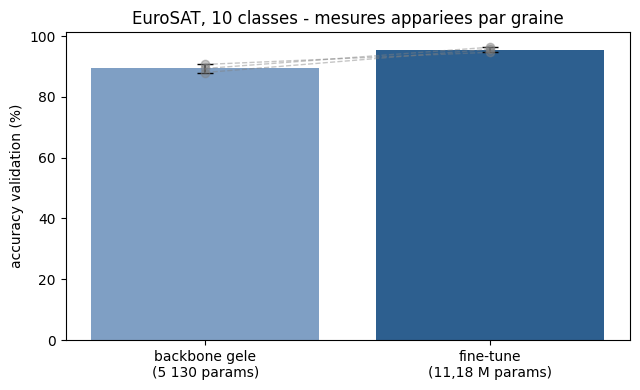

In [7]:
resultats = {"gele": [], "finetune": []}
t_debut = time.time()
for graine in GRAINES:
    acc_g, _, _ = entrainer_gele(graine)
    acc_f, _ = entrainer_finetune(graine)
    resultats["gele"].append(acc_g)
    resultats["finetune"].append(acc_f)
    print(f"graine {graine} : gele {100 * acc_g:.1f} % | finetune {100 * acc_f:.1f} % | "
          f"ecart {100 * (acc_f - acc_g):+.1f} pts")
budget_total = time.time() - t_debut

gele = np.array(resultats["gele"])
finetune = np.array(resultats["finetune"])
ecarts = finetune - gele

# Test exact de permutation des signes (n = 3 -> 8 configurations).
signes = list(product((-1.0, 1.0), repeat=len(ecarts)))
moyennes_perm = [np.mean(np.array(s) * ecarts) for s in signes]
p_valeur = np.mean(np.abs(moyennes_perm) >= np.abs(ecarts.mean()) - 1e-12)

bruit = ecarts.std(ddof=1)
print()
print(f"gele     : {100 * gele.mean():.1f} % +/- {100 * gele.std(ddof=1):.1f}")
print(f"finetune : {100 * finetune.mean():.1f} % +/- {100 * finetune.std(ddof=1):.1f}")
print(f"ecart apparie moyen : {100 * ecarts.mean():+.1f} pts (bruit inter-graines {100 * bruit:.1f} pts, "
      f"rapport {abs(ecarts.mean()) / bruit:.1f})")
print(f"test de permutation des signes : p = {p_valeur:.3f} (plancher 1/{len(signes)} = {1 / len(signes):.3f})")
print(f"budget total des 6 entrainements : {budget_total:.0f} s")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar([0, 1], [100 * gele.mean(), 100 * finetune.mean()],
       yerr=[100 * gele.std(ddof=1), 100 * finetune.std(ddof=1)],
       capsize=6, color=["#7f9fc4", "#2d5f8f"])
for g, f in zip(gele, finetune):
    ax.plot([0, 1], [100 * g, 100 * f], "o--", color="gray", alpha=0.45, lw=1)
ax.set_xticks([0, 1], ["backbone gele\n(5 130 params)", "fine-tune\n(11,18 M params)"])
ax.set_ylabel("accuracy validation (%)")
ax.set_title("EuroSAT, 10 classes - mesures appariees par graine")
plt.tight_layout()
plt.show()

**Lecture de la comparaison.** Les trois graines racontent la même histoire : gelé 89,3 % ± 1,3, fine-tuné 95,6 % ± 0,8, écart apparié moyen **+6,2 points** — et les trois écarts sont positifs (+7,7, +7,0, +4,0). Le test de permutation des signes rend p = 0,250 : parmi les 8 configurations de signes possibles, deux produisent une moyenne aussi extrême que l'observée (la configuration inversée, symétrique, et l'observée elle-même) — l'écart le plus petit (+4,0) ne suffit pas à écarter les configurations mixtes. Autrement dit : l'effet va **trois fois dans le même sens** avec un rapport signal/bruit de 3,2, mais à n = 3 le test est trop peu puissant pour dire mieux — c'est la limite écrite d'avance, pas une étoile de significativité.

La hiérarchie des moyennes cache un détail instructif : le gelé est **plus dispersé** (± 1,3) que le fine-tuné (± 0,8). Le régime gelé dépend entièrement de ce que le tirage a donné — sa frontière est aussi bonne que les caractéristiques figées le permettent, point final. Le fine-tuning, lui, compense : il ajuste l'extracteur au domaine *et* au tirage, ce qui le rend à la fois meilleur en moyenne et plus prévisible.

**Quand le gel suffit-il alors ?** La réponse honnête de cette mesure : **souvent**. 89 % avec 5 130 paramètres entraînés, ~7 s de calcul et aucun risque de casser le pré-entraînement — c'est un excellent choix par défaut, et le premier réflexe à tester. Le fine-tuning se justifie quand (a) le décalage de domaine est grand — c'est le cas ici, et il récupère 6,2 points ; (b) ces points ont une valeur — un produit en production n'y renonce pas, un prototype s'en passe ; (c) on sait le faire prudemment — la section 4 a montré qu'un protocole naïf peut *perdre* contre le gelé.

La règle de décision n'est pas « toujours fine-tuner » mais : **gelé d'abord, mesurer, ne dégeler que si l'écart vaut le coût**. C'est exactement ce qu'explore l'exercice 2 (dégeler un seul étage, l'entre-deux).

***

## 6. Exercices


Trois exercices, du plus guidé au plus ouvert. Chaque cellule s'exécute telle quelle : tant que le stub n'est pas complété, elle affiche « Exercice à compléter » et le notebook continue. Les consignes suivent la convention de la série : `# TODO`, `# Indice`, `# Étape N`.

### Exercice 1 — few-shot : et avec 20 images par classe ?

Le régime gelé brille quand les données manquent. Réduisez le sous-ensemble d'entraînement à **20 images par classe** (gardez 30 en validation) et mesurez l'accuracy du régime gelé, puis celle du fine-tuning. Le rapport entre les deux régimes se resserre-t-il, s'inverse-t-il, ou reste-t-il ? Répondez en une phrase : que fait le fine-tuning avec 200 images qu'il ne devrait pas ?

In [8]:
def entrainer_gele_fewshot(graine, par_classe=20):
    """TODO etudiant : variante few-shot du regime gele.

    Etape 1 : copier le corps de `entrainer_gele` (section 3).
    Etape 2 : restreindre le tirage a `par_classe` images d'entrainement
              (la validation garde PAR_CLASSE_VAL = 30 images par classe).
    Indice : le plus simple est de tronquer idx_train APRES le tirage
             de `sous_ensemble`, avant `charger_tenseurs`.
    """
    pass  # TODO etudiant
    return None  # TODO etudiant : renvoyer l'accuracy de validation


acc_fewshot = entrainer_gele_fewshot(0)
if acc_fewshot is not None:
    print(f"gele few-shot (20/classe) : {100 * acc_fewshot:.1f} % "
          f"(vs {100 * acc_gele_0:.1f} % a {PAR_CLASSE_TRAIN}/classe)")
else:
    print("Exercice a completer : remplir `entrainer_gele_fewshot` (Exercice 1).")

Exercice a completer : remplir `entrainer_gele_fewshot` (Exercice 1).


### Exercice 2 — dégel partiel : seulement `layer4`

Le dilemme gelé / tout-dégeler a un entre-deux : dégeler **uniquement le dernier étage** (`layer4`, le plus spécialisé, le plus proche de la tête) et laisser le reste figé. Mesurez l'accuracy et le nombre de paramètres entraînés, et situez ce point entre les deux régimes extrêmes de la section 5.

In [9]:
def entrainer_layer4(graine, epochs=5):
    """TODO etudiant : degeler seulement layer4 + la tete.

    Etape 1 : construire le modele comme dans `entrainer_finetune` (section 4).
    Etape 2 : geler tous les parametres SAUF ceux de `layer4` et `fc`
              (boucle sur `modele.named_parameters()`, `p.requires_grad_(False)`).
    Etape 3 : ne passer a l'optimiseur que les parametres encore entrainables
              (`p for p in modele.parameters() if p.requires_grad`).
    Indice : compter les parametres entraines avec
             `sum(p.numel() for p in modele.parameters() if p.requires_grad)`.
    """
    pass  # TODO etudiant
    return None  # TODO etudiant : renvoyer (accuracy, nb_parametres_entraines)


resultat_layer4 = entrainer_layer4(0)
if resultat_layer4 is not None:
    acc_l4, n_params = resultat_layer4
    print(f"layer4 + tete : {100 * acc_l4:.1f} % avec {n_params:,d} parametres entraines")
else:
    print("Exercice a completer : remplir `entrainer_layer4` (Exercice 2).")

Exercice a completer : remplir `entrainer_layer4` (Exercice 2).


### Exercice 3 — analyse d'erreurs : où le modèle se trompe-t-il ?

L'accuracy globale cache la structure des erreurs. Écrivez `matrice_confusion(modele, idx_val)` qui renvoie la matrice 10 x 10 des comptes (ligne = classe vraie, colonne = prédiction), affichez-la avec `plt.imshow`, et identifiez la paire de classes la plus confondue. La section 1 en annonçait une candidate — vérifiez.

In [10]:
def matrice_confusion(modele, idx_val):
    """TODO etudiant : matrice 10 x 10 des comptes d'erreurs.

    Etape 1 : collecter les predictions du modele sur idx_val (mode eval,
              torch.no_grad, par lots de 64 - meme squelette que l'evaluation
              de `entrainer_finetune`).
    Etape 2 : remplir M[vraie, predicte] += 1 pour chaque image.
    Etape 3 : afficher avec plt.imshow(M) et plt.colorbar, etiquettes = LIBELLES.
    Indice : la paire la plus confondue maximise M[i, j] + M[j, i] pour i != j.
    """
    pass  # TODO etudiant
    return None  # TODO etudiant : renvoyer la matrice numpy (10, 10)


M = matrice_confusion(dernier_modele, idx_val)
if M is not None:
    fig, ax = plt.subplots(figsize=(7, 6))
    image_ax = ax.imshow(M, cmap="Blues")
    ax.set_xticks(range(10), LIBELLES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10), LIBELLES, fontsize=8)
    ax.set_xlabel("predicte")
    ax.set_ylabel("vraie classe")
    fig.colorbar(image_ax)
    plt.tight_layout()
    plt.show()
else:
    print("Exercice a completer : remplir `matrice_confusion` (Exercice 3).")

Exercice a completer : remplir `matrice_confusion` (Exercice 3).


***

## 7. Ce qu'il faut retenir


**Ce qu'il faut retenir.**

1. **Le transfer learning est un choix de budget, pas un geste rituel.** Gelé : 5 130 paramètres, ~7 s, 89,3 % ± 1,3. Fine-tuné : 11,18 M paramètres, ~84 s, 95,6 % ± 0,8. Sur EuroSAT les deux sont défendables — la décision dépend de ce que valent 6 points dans votre application.
2. **Les caractéristiques ImageNet généralisent plus loin qu'on ne le craint.** 88-91 % sur des images satellite avec une simple frontière linéaire : le pré-entraînement a appris des textures et des régularités, pas juste des « objets ».
3. **Le fine-tuning à taux constants est un piège mesuré.** Sans planificateur, l'optimiseur oscillait et finissait sous le gelé ; avec décroissance x0,3 par époque et batch 64, il gagne 6 points systématiquement. Sur petit jeu de données, le *planning* du taux d'apprentissage fait partie du modèle.
4. **La même idée structure le reste de la série.** Le backbone figé dont on réapprend la tête, c'est le transformer pré-entraîné du [3.4](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb) dont on réapprend la projection ; les blocs résiduels qu'on gèle ou dégelte sont ceux du [4.2](4.2-ConvNet-Profonde-Residuelles.ipynb). Et quand [Track2](../Track2-GoogleADK/README.md) charge un modèle via un outil ADK, c'est ce même contrat — un extracteur réutilisable, une tête à soi.

**Pour aller plus loin.** He et al., *Deep Residual Learning for Image Recognition* (2015) — le backbone ; le tutoriel torchvision *Transfer Learning for Computer Vision* — les conventions du domaine ; Helber et al., *Introducing EuroSAT* (2019) — le dataset.